In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

In [41]:
base = Path.cwd().parent

In [42]:
part1 = pd.read_json(base / "data" / "Streaming_History_Audio_2025_1.json")
part2 = pd.read_json(base / "data" / "Streaming_History_Audio_2022-2025_0.json")
df = pd.concat([part1, part2], ignore_index=True)

In [43]:
df.dropna(axis=1, how='all', inplace=True)
df.drop(columns=['ip_addr'], inplace=True)

In [44]:
df['ts'] = pd.to_datetime(df['ts'])
df['platform'] = df['platform'].astype('category')
df['conn_country'] = df['conn_country'].astype('category')
df['reason_start'] = df['reason_start'].astype('category')
df['reason_end'] = df['reason_end'].astype('category')
df['shuffle'] = df['shuffle'].astype('boolean')
df['skipped'] = df['skipped'].astype('boolean')
df['offline'] = df['offline'].astype('boolean')
df['incognito_mode'] = df['incognito_mode'].astype('boolean')

In [45]:
df['ms_played'] = df['ms_played'] / 1000 / 60  # Convert to minutes

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17648 entries, 0 to 17647
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype              
---  ------                             --------------  -----              
 0   ts                                 17648 non-null  datetime64[ns, UTC]
 1   platform                           17648 non-null  category           
 2   ms_played                          17648 non-null  float64            
 3   conn_country                       17648 non-null  category           
 4   master_metadata_track_name         17646 non-null  object             
 5   master_metadata_album_artist_name  17646 non-null  object             
 6   master_metadata_album_album_name   17646 non-null  object             
 7   spotify_track_uri                  17646 non-null  object             
 8   audiobook_title                    2 non-null      object             
 9   audiobook_uri                      2 non-null     

<Axes: >

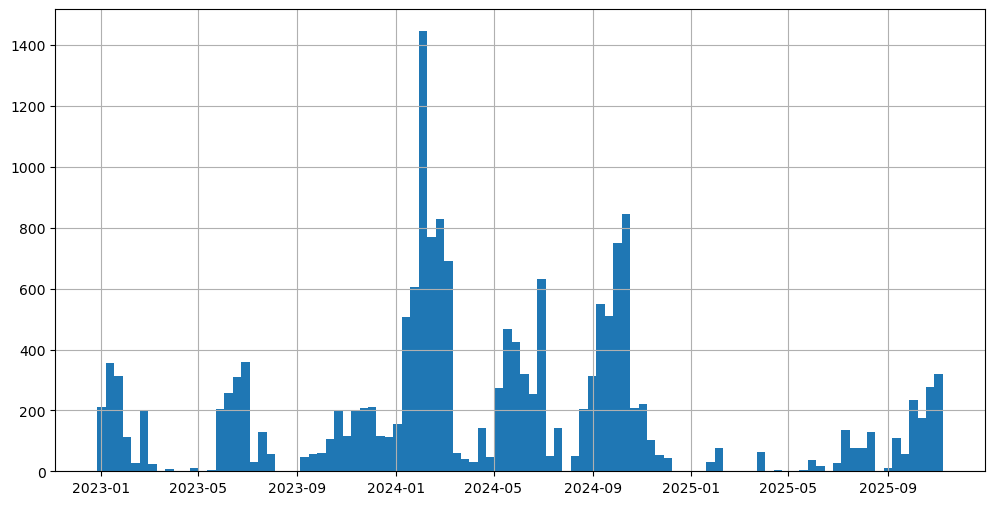

In [47]:
df['ts'].hist(bins=100, figsize=(12, 6))

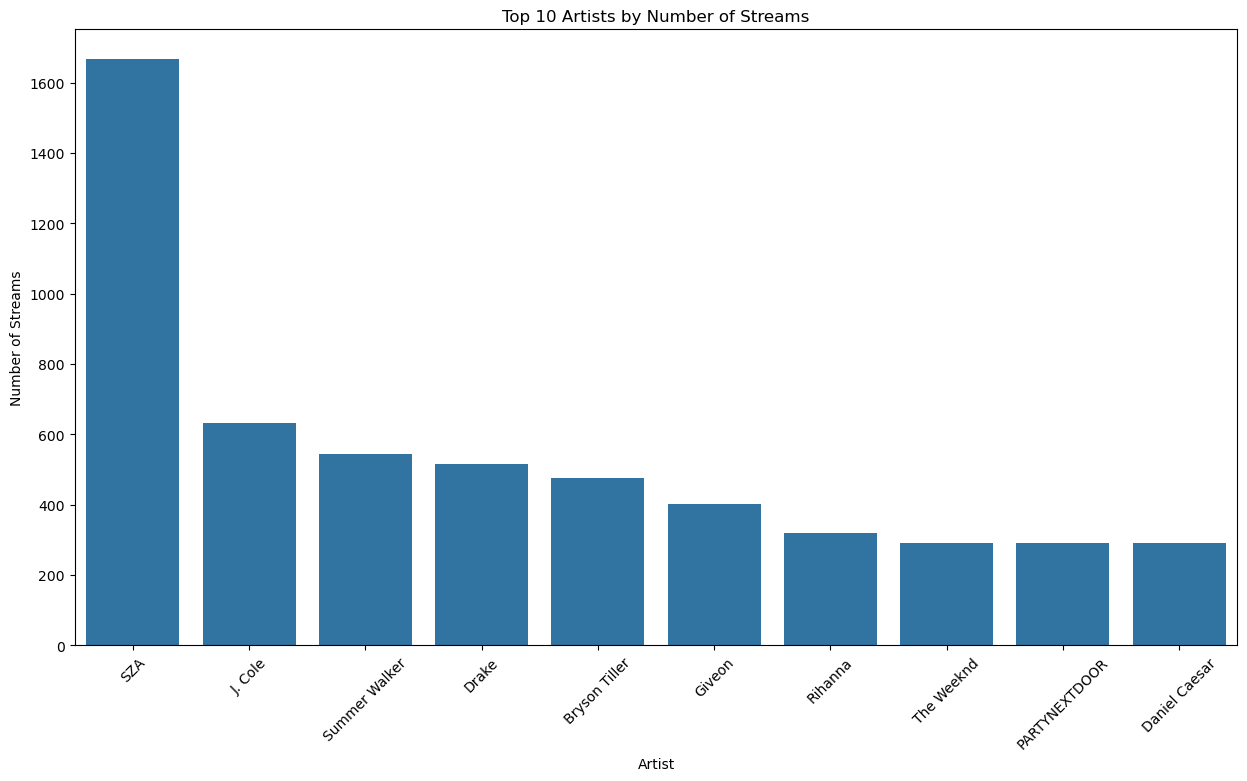

In [48]:
tmp = df['master_metadata_album_artist_name'].value_counts()
plt.figure(figsize=(15, 8))
sns.barplot(x=tmp.index[:10], y=tmp.values[:10])
plt.xticks(rotation=45)
plt.title('Top 10 Artists by Number of Streams')
plt.xlabel('Artist')
plt.ylabel('Number of Streams')
# plt.tight_layout()
plt.show()

In [49]:
df

,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,audiobook_title,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode
0,2025-07-14 15:03:40+00:00,windows,2.387100,ET,Playing Games (with Bryson Tiller) - Extended ...,Summer Walker,Over It,spotify:track:2xyx0o4xNOLLjBSbOOdcbA,NaN,NaN,NaN,NaN,playbtn,trackdone,True,False,False,1752505275,False
1,2025-07-14 15:05:30+00:00,windows,1.823550,ET,BP,Summer Walker,Last Day Of Summer,spotify:track:7B1c8GzIeRVfuU7pqgmBaR,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1752505420,False
2,2025-07-14 15:09:20+00:00,windows,3.387333,ET,CPR,Summer Walker,Last Day Of Summer,spotify:track:5Tp4UJvnsF4Zd05k0zXUte,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1752505556,False
3,2025-07-14 15:12:06+00:00,windows,2.750000,ET,Spend It,Summer Walker,Spend It,spotify:track:290eKCMBc9f9CcSLFuQrim,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1752505760,False
4,2025-07-14 15:15:06+00:00,windows,2.999550,ET,I'll Kill You (feat. Jhené Aiko),Summer Walker,Over It,spotify:track:7EkiMl81fUHVwpItgtzI4r,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1752505926,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17643,2025-07-13 03:17:50+00:00,android,3.424300,ET,Calling My Phone,Lil Tjay,Destined 2 Win,spotify:track:3J8EOeKLTLXORtWPpOU5bE,None,None,None,None,trackdone,trackdone,True,False,False,1752376252,False
17644,2025-07-13 04:17:14+00:00,windows,4.047050,ET,2AM,SZA,Ctrl (Deluxe),spotify:track:3vZGtceCbJVh5aDT4XhE0p,None,None,None,None,clickrow,trackdone,False,False,False,1752379988,False
17645,2025-07-13 04:18:49+00:00,windows,1.162133,ET,Miles,SZA,Ctrl (Deluxe),spotify:track:4pHy0gmjfpD0Fgond5c4Ta,None,None,None,None,trackdone,trackdone,False,False,False,1752380259,False
17646,2025-07-13 04:20:13+00:00,windows,1.400000,ET,Percolator,SZA,Ctrl (Deluxe),spotify:track:4UJuFZ4btsiGqMyFHBRPbo,None,None,None,None,trackdone,trackdone,False,False,False,1752380328,False


In [50]:
artist_stats = df.groupby('master_metadata_album_artist_name').agg(
    total_plays=('ts', 'count'),
    skips=('skipped', 'sum')
)
artist_stats['skip_rate'] = artist_stats['skips'] / artist_stats['total_plays']


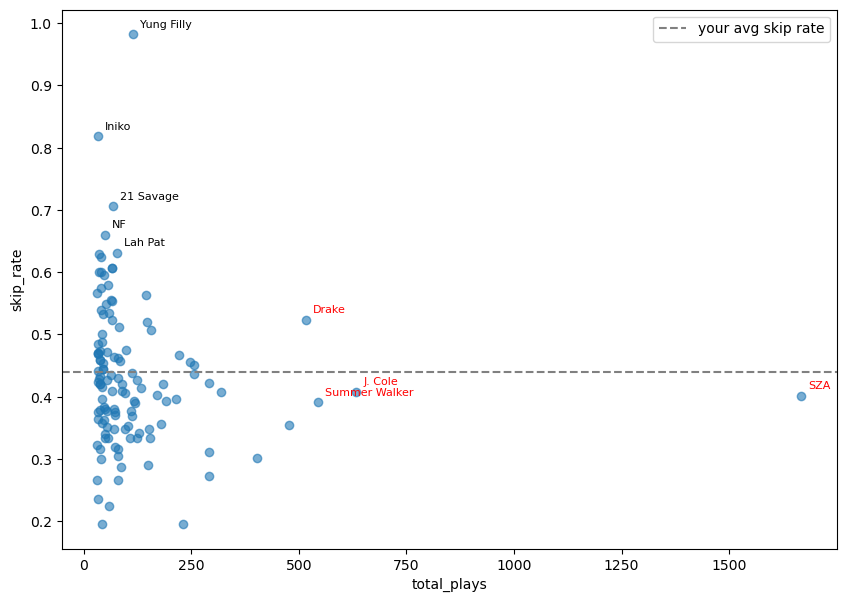

In [51]:
# only keep artists with a reasonable sample size, otherwise low-n noise dominates
filtered = artist_stats[artist_stats['total_plays'] >= 30].copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(filtered['total_plays'], filtered['skip_rate'], alpha=0.6)

# label only the extremes so it's not cluttered
top_candidates = filtered.sort_values('skip_rate', ascending=False).head(5)
top_favorite = filtered.sort_values('total_plays', ascending=False).head(4)

for name, row in top_candidates.iterrows():
    ax.annotate(name, (row['total_plays'], row['skip_rate']), fontsize=8, xytext=(5,5), textcoords='offset points')
for name, row in top_favorite.iterrows():
    ax.annotate(name, (row['total_plays'], row['skip_rate']), fontsize=8, color='red', xytext=(5,5), textcoords='offset points')

ax.axhline(df['skipped'].mean(), color='gray', linestyle='--', label='your avg skip rate')
ax.set_xlabel('total_plays')
ax.set_ylabel('skip_rate')
ax.legend()
plt.show()

In [52]:
track_stats = df.groupby('master_metadata_track_name').agg(
    total_plays=('ts', 'count'),
    skips=('skipped', 'sum')
)
track_stats['skip_rate'] = track_stats['skips'] / track_stats['total_plays']

# filter out artists you've barely played, otherwise n=1 100%-skip artists dominate
track_stats[track_stats['total_plays'] >= 10].sort_values('skip_rate', ascending=False)

,total_plays,skips,skip_rate
master_metadata_track_name,,,
Grey,115,113,0.982609
She Make It Clap,15,14,0.933333
Yosemite (Song For The Ahwahnechee),14,13,0.928571
Drip Too Hard (Lil Baby & Gunna),13,11,0.846154
Rich Baby Daddy (feat. Sexyy Red & SZA),31,26,0.83871
...,...,...,...
STRANGERS,12,1,0.083333
See You Again (feat. Kali Uchis),14,1,0.071429
I CAN TELL,12,0,0.0


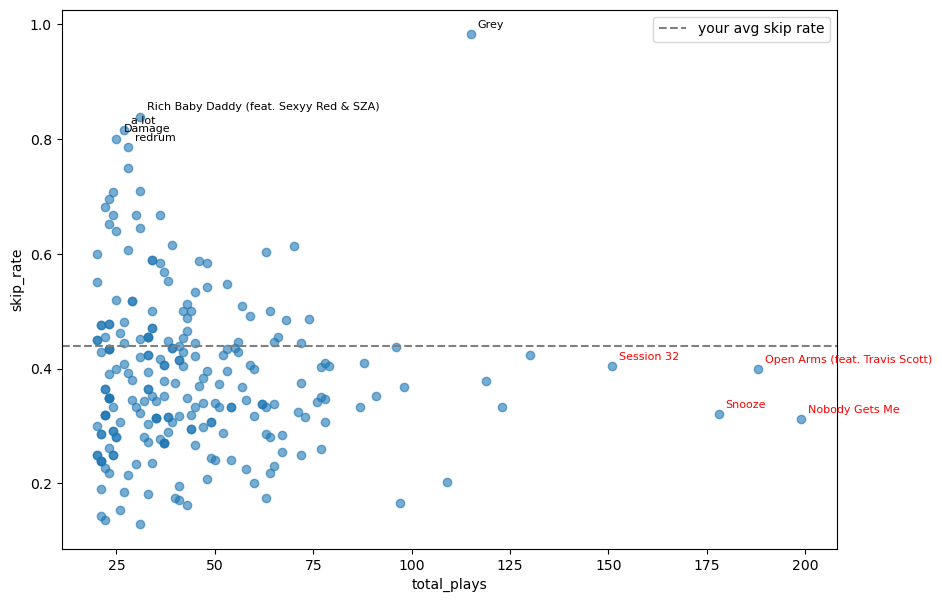

In [53]:
# only keep artists with a reasonable sample size, otherwise low-n noise dominates
filtered = track_stats[track_stats['total_plays'] >= 20].copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(filtered['total_plays'], filtered['skip_rate'], alpha=0.6)

# label only the extremes so it's not cluttered
top_candidates = filtered.sort_values('skip_rate', ascending=False).head(5)
top_favorite = filtered.sort_values('total_plays', ascending=False).head(4)

for name, row in top_candidates.iterrows():
    ax.annotate(name, (row['total_plays'], row['skip_rate']), fontsize=8, xytext=(5,5), textcoords='offset points')
for name, row in top_favorite.iterrows():
    ax.annotate(name, (row['total_plays'], row['skip_rate']), fontsize=8, color='red', xytext=(5,5), textcoords='offset points')

ax.axhline(df['skipped'].mean(), color='gray', linestyle='--', label='your avg skip rate')
ax.set_xlabel('total_plays')
ax.set_ylabel('skip_rate')
ax.legend()
plt.show()

In [61]:
from scipy.stats import binomtest

global_skip_rate = df['skipped'].mean()  # your overall skip rate across everything

def skip_surprise(artist_name, p=global_skip_rate):
    skips = artist_stats.loc[artist_name, 'skips']
    plays = artist_stats.loc[artist_name, 'total_plays']
    result = binomtest(skips, plays, p, alternative='greater')
    return result.pvalue  # small = surprising, this artist isn't "just average"

In [65]:
artist_stats['skip_surprise'] = artist_stats.index.map(skip_surprise)

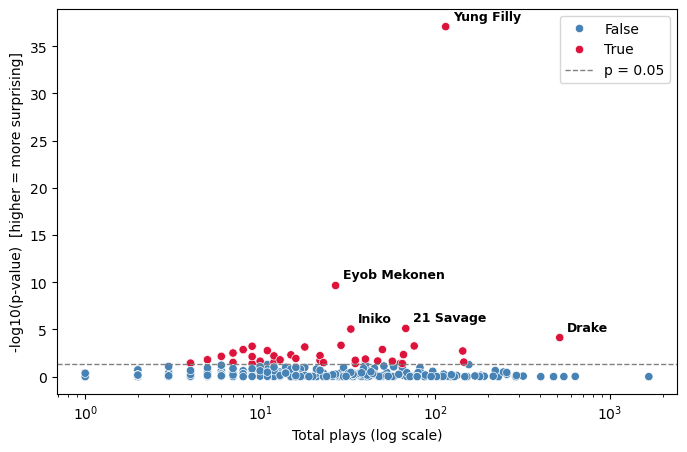

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# avoid log(0) for any p-values that underflowed to exactly 0
artist_stats['neg_log_p'] = -np.log10(artist_stats['skip_surprise'].clip(lower=1e-300))
artist_stats['significant'] = artist_stats['skip_surprise'] < 0.05

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=artist_stats, x='total_plays', y='neg_log_p',
    hue='significant', palette={True: 'crimson', False: 'steelblue'},
    ax=ax
)
top3 = artist_stats.nsmallest(5, 'skip_surprise')

for _, row in top3.iterrows():
    ax.annotate(
        row.name,  # swap this for whatever your artist name column is actually called
        xy=(row['total_plays'], row['neg_log_p']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=9, fontweight='bold'
    )
ax.set_xscale('log')
ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=1, label='p = 0.05')
ax.set_xlabel('Total plays (log scale)')
ax.set_ylabel('-log10(p-value)  [higher = more surprising]')
ax.legend()
plt.show()

In [89]:
from statsmodels.stats.proportion import proportion_confint

artist_stats['low'], artist_stats['high'] = zip(*artist_stats.apply(
    lambda row: proportion_confint(count=row['skips'], nobs=row['total_plays'], alpha=0.05, method='wilson'),
    axis=1
))

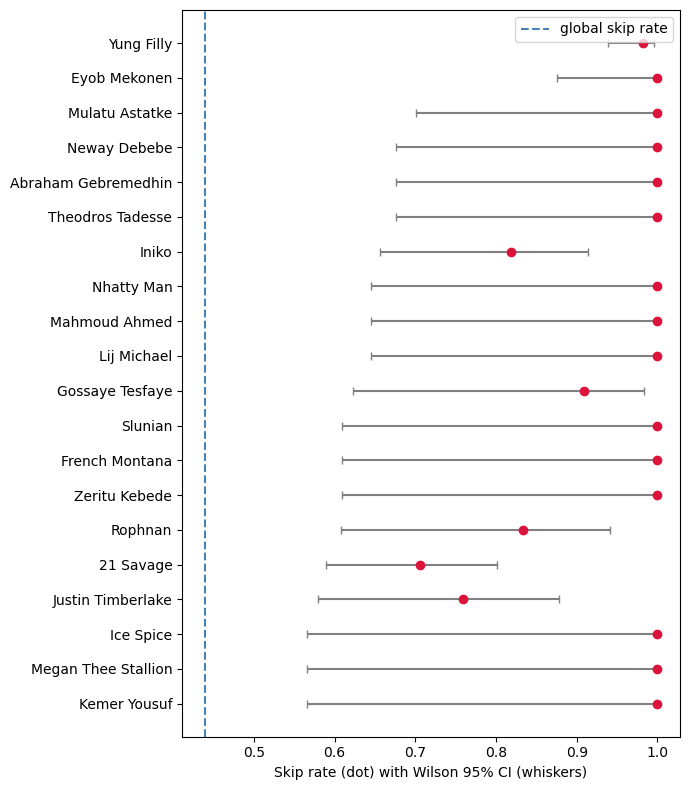

In [101]:
top_n = 20
artist_stats['raw_rate'] = artist_stats['skips'] / artist_stats['total_plays']

# sort by 'low', not raw_rate -- this IS the point of the whole exercise
top = artist_stats.nlargest(top_n, 'low').sort_values('low')

fig, ax = plt.subplots(figsize=(7, 8))
y_pos = range(len(top))

xerr_low = np.clip(top['raw_rate'] - top['low'], 0, None)
xerr_high = np.clip(top['high'] - top['raw_rate'], 0, None)

ax.errorbar(
    top['raw_rate'], y_pos,
    xerr=[xerr_low, xerr_high],
    fmt='o', color='crimson', ecolor='gray', capsize=3
)
ax.axvline(global_skip_rate, color='steelblue', linestyle='--', label='global skip rate')
ax.set_yticks(y_pos)
ax.set_yticklabels(top.index)
ax.set_xlabel('Skip rate (dot) with Wilson 95% CI (whiskers)')
ax.legend()
plt.tight_layout()
plt.show()

In [99]:
top

,total_plays,skips,skip_rate,skip_surprise,neg_log_p,significant,low,high,raw_rate
master_metadata_album_artist_name,,,,,,,,,
Kemer Yousuf,5,5,1.0,1.630010e-02,1.787810,True,0.565518,1.000000,1.0
Megan Thee Stallion,5,5,1.0,1.630010e-02,1.787810,True,0.565518,1.000000,1.0
Ice Spice,5,5,1.0,1.630010e-02,1.787810,True,0.565518,1.000000,1.0
Justin Timberlake,29,22,0.758621,4.802319e-04,3.318549,True,0.578924,0.877816,0.758621
21 Savage,68,48,0.705882,7.803165e-06,5.107729,True,0.588937,0.800810,0.705882
Rophnan,18,15,0.833333,7.243849e-04,3.140031,True,0.607780,0.941634,0.833333
Zeritu Kebede,6,6,1.0,7.155309e-03,2.145372,True,0.609666,1.000000,1.0
French Montana,6,6,1.0,7.155309e-03,2.145372,True,0.609666,1.000000,1.0
Slunian,6,6,1.0,7.155309e-03,2.145372,True,0.609666,1.000000,1.0


In [94]:
artist_stats

,total_plays,skips,skip_rate,skip_surprise,neg_log_p,significant,low,high,raw_rate
master_metadata_album_artist_name,,,,,,,,,
$hyfromdatre,47,18,0.382979,0.821028,0.085642,False,0.257907,0.525734,0.382979
21 Savage,68,48,0.705882,0.000008,5.107729,True,0.588937,0.800810,0.705882
2KJ,1,1,1.0,0.438973,0.357562,False,0.206549,1.000000,1.0
2Pac,63,35,0.555556,0.041640,1.380489,True,0.433196,0.671529,0.555556
4batz,6,2,0.333333,0.822430,0.084901,False,0.096771,0.700007,0.333333
...,...,...,...,...,...,...,...,...,...
thủy,1,1,1.0,0.438973,0.357562,False,0.206549,1.000000,1.0
ya boi ivan,5,2,0.4,0.726979,0.138478,False,0.117621,0.769276,0.4
¥$,13,10,0.769231,0.016678,1.777867,True,0.497436,0.918205,0.769231


In [105]:
mismatch.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   total_plays    0 non-null      int64  
 1   skips          0 non-null      Int64  
 2   skip_rate      0 non-null      Float64
 3   skip_surprise  0 non-null      float64
 4   neg_log_p      0 non-null      float64
 5   significant    0 non-null      bool   
 6   low            0 non-null      float64
 7   high           0 non-null      float64
 8   raw_rate       0 non-null      Float64
dtypes: Float64(2), Int64(1), bool(1), float64(4), int64(1)
memory usage: 0.0+ bytes
